**Libraries Importation**

Firstly the following libraries were imported:


*   **pandas** : Here, it loads CSV files, cleans and preprocesses the data as well as transforms them.
*   **matplotlib** : Here, it provides control over the figure size, axis labels, titles and layout. Also, seaborn is built on top of matplotlib, but the latter is still required for the figure customization.


*   **seaborn** : Here, it has helped create plots in an easier manner with fewer lines of code than matplotlib. It also works directly with the Pandas DataFrames
*   **RobustScaler from sklearn.preprocessing** : It has been used for feature scaling as it is resistant to the effect of outliers.





In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
import seaborn as sns

**Loading CSV**

The CSV is uploaded into a github repository through which it is imported.

In [ ]:
url = 'https://raw.githubusercontent.com/9lixir/Data-Pipeline-Assignment/refs/heads/main/Airline_Delay_Cause.csv'
df = pd.read_csv(url)

Here, the first five records of the dataset of the dataset have been loaded so that there is an idea of the kind of data we are working with.

In [ ]:
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


Before cleaning, the number of null records each column contains has been checked.

In [ ]:
df.isnull().sum()

,0
year,0
month,0
carrier,0
carrier_name,0
airport,0
airport_name,0
arr_flights,240
arr_del15,443
carrier_ct,240
weather_ct,240


In [ ]:
df.columns

Index(['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name',
       'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct',
       'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
       'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay',
       'security_delay', 'late_aircraft_delay'],
      dtype='object')

**Data Cleaning**

For the cleaning of data,  a list of the columns that have null values in them has been created. Iterating through the list, the null-valued records have been filled with the mean of all the records of that specific column.

The redundant columns such as carrier_name and airport_name have been dropped since information regarding these attributes can be obtained from 'carrier' and 'airport' columns respectively.

In [ ]:
# cleaning of data
# making a list of columns that need to be cleaned
columns_to_clean =[
    'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct',
    'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
    'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay',
    'security_delay', 'late_aircraft_delay'
]

# looping through the columns to clean them

for col in columns_to_clean:
  df[col] = df[col].fillna(df[col].mean())

# redundant columns, so we drop it
drop_cols = ['carrier_name', 'airport_name']
df = df.drop(columns=drop_cols)

This step is done as a confirmation to check whether the code above worked to fill the null values.

In [ ]:
df.isnull().sum()

,0
year,0
month,0
carrier,0
airport,0
arr_flights,0
arr_del15,0
carrier_ct,0
weather_ct,0
nas_ct,0
security_ct,0


**Feature Scaling**

Here, Robust Scaler has been chosen as the scaler since the dataset contains significant outliers. RobustScaler is a safe choice since it is outliers resistant.

A list of columns has been created. Here, the columns that are chosen are the attributes that are the cause of delays. So they are scaled using the RobustScaler.

In [ ]:
# scaling the data
scaler = RobustScaler()

# choosing the columns we want to scale. here, we choose columns that cause the delays
columns_to_scale = [
    'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct',
    'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay'
]

df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

**Feature Transformation**

There are columns such as 'carrier' and 'airport' that are nominal categorical data. One column, 'carrier' has been one hot encoded.

Airport has been left as it is for easier plot visualization.

In [ ]:
# one hot encoding for the carrier column

if 'carrier' in df.columns:
  df = pd.get_dummies(df, columns =['carrier'],drop_first=True)
else:
  print("One hot encoding is already done for the carrier column.")

In [ ]:
df.columns

Index(['year', 'month', 'airport', 'arr_flights', 'arr_del15', 'carrier_ct',
       'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct',
       'arr_cancelled', 'arr_diverted', 'arr_delay', 'carrier_delay',
       'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay',
       'carrier_AA', 'carrier_AS', 'carrier_B6', 'carrier_DL', 'carrier_EV',
       'carrier_F9', 'carrier_FL', 'carrier_G4', 'carrier_HA', 'carrier_MQ',
       'carrier_NK', 'carrier_OH', 'carrier_OO', 'carrier_QX', 'carrier_UA',
       'carrier_US', 'carrier_VX', 'carrier_WN', 'carrier_YV', 'carrier_YX'],
      dtype='object')

The cleaned dataset is loaded as Cleaned_Airline_Delay_Cause.csv. A message is printed as a confirmation.

In [ ]:
# loading the cleaned dataset
df.to_csv("Cleaned_Airline_Delay_Cause.csv", index = False)
print("Pipeline completed. Cleaned dataset is loaded.")

Pipeline completed. Cleaned dataset is loaded.


**Correlation Heatmap**

The Correlation Heatmap is used to visualize the pairwise relationships between numerical attributes in the airline delay dataset. To create the visualiztion, the following steps were performed:



1. Relevant columns were selected for the analysis.
2. The correlation matrix was computed using the .corr() function.
3. The matrix was visualized using Seaborn's heatmap.

**Observations:**

1. There is a near-perfect positive correlation (0.97) between arr_del15 (number of delayed flights) and arr_delay (total delay minutes). This tells us that as the frequency of late flights increases, the total time lost scales almost identically.
2. The correlation between late_aircraft_ct and arr_delay is extremely high (0.92). This shows that a single plane arriving late for its first flight of the day causes a chain reaction that impacts all its subsequent flights.
3. carrier_ct (internal airline issues) has a much higher correlation with total delay minutes (0.91) than weather_ct does (0.80). While weather gets the most news coverage, airline-controlled factors (like maintenance or staffing)  statistically drive total delay time more in this dataset.
4. nas_ct shows a very high correlation (0.91) with the number of delayed flights (arr_del15). This suggests that air traffic control and airport operations are highly sensitive to flight volume.
5. There is a high correlation (0.88) between the total number of flights (arr_flights) and total delay minutes (arr_delay). This shows that more traffic almost always results in more significant delays.



<Axes: >

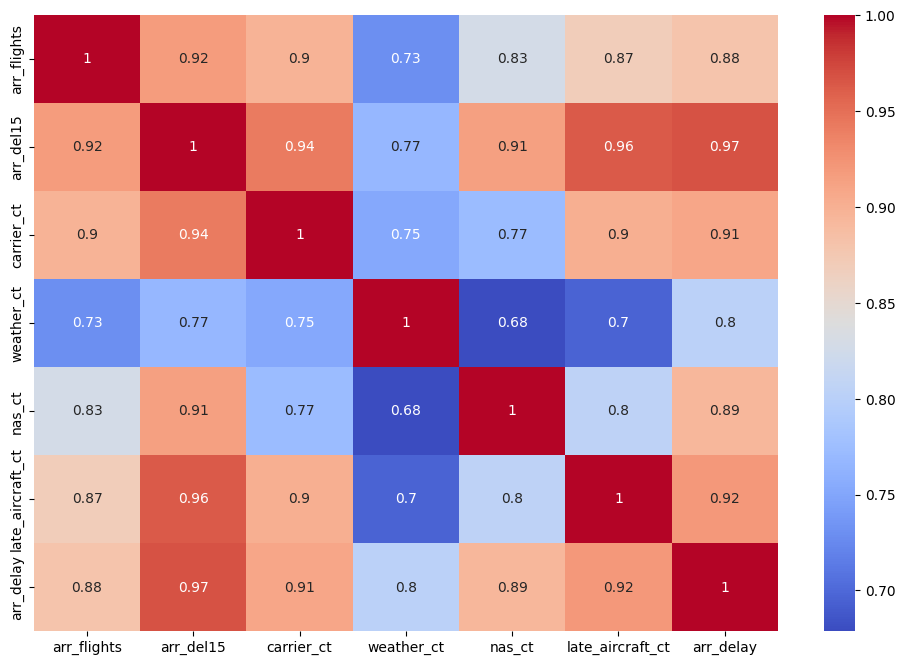

In [ ]:
# correlation heatmap
plt.figure(figsize=(12,8))

# choosing specific columns for the heatmap

heatmap_cols = [
    'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct',
    'nas_ct', 'late_aircraft_ct', 'arr_delay'
]

correlation_matrix = df[heatmap_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot = True,
    cmap = 'coolwarm',
)

**Distribution of Numerical Attributes**

The distribution plots are used to visualize how values are spead for each numerical attribute in the dataset which in turn helps to identify aptterns, skewness, outliers, and overall data ranges.

**Steps:**
1. Numerical columns that are relevant to flight delays were selected.
2. Seaborn's histplot was used to create histograms
3. Plot labels and limits were set.
4. Optional lof scale is commented out, initially used for testing but the linear scaling was chosen for the raw readability. (for highly skewed data).

**Observations:**

1. All delay-related attributes (e.g., weather_delay, nas_delay) exhibit heavy right-skewness. Most values are clustered near zero, with a small number of extreme events stretching the x-axis.
2. Attributes like security_delay show very high frequency at zero, indicating these events are rare compared to carrier_delay or late_aircraft_delay.
3. The extreme range observed in these histograms (often spanning from 0 to several thousand minutes) justifies the use of RobustScaler, as a standard mean-based scaler would be heavily distorted by these high-value outliers.

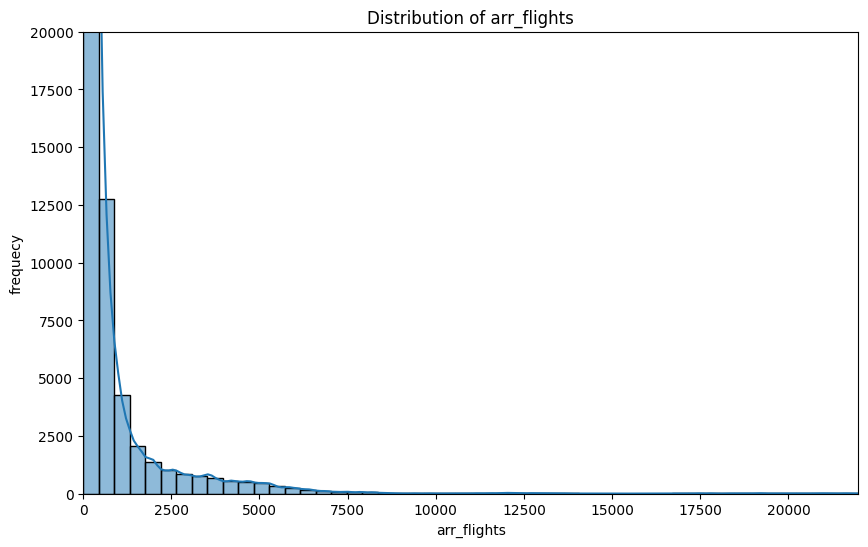

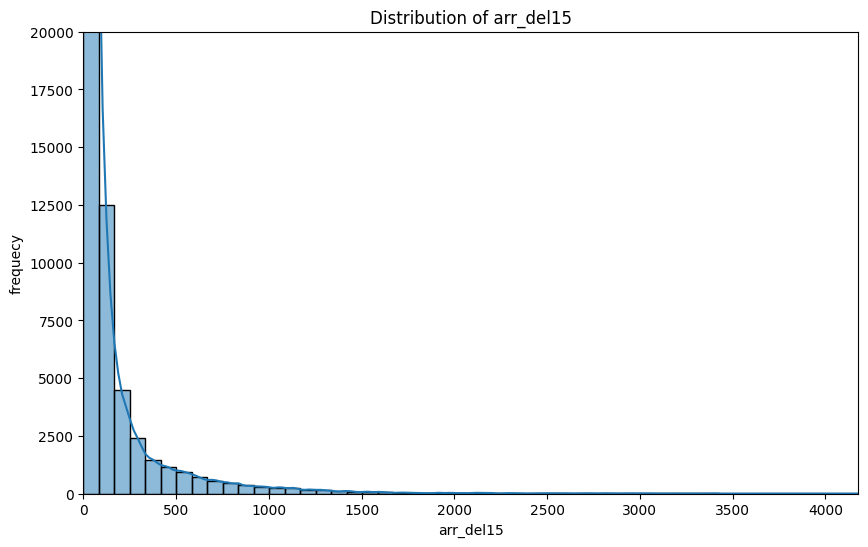

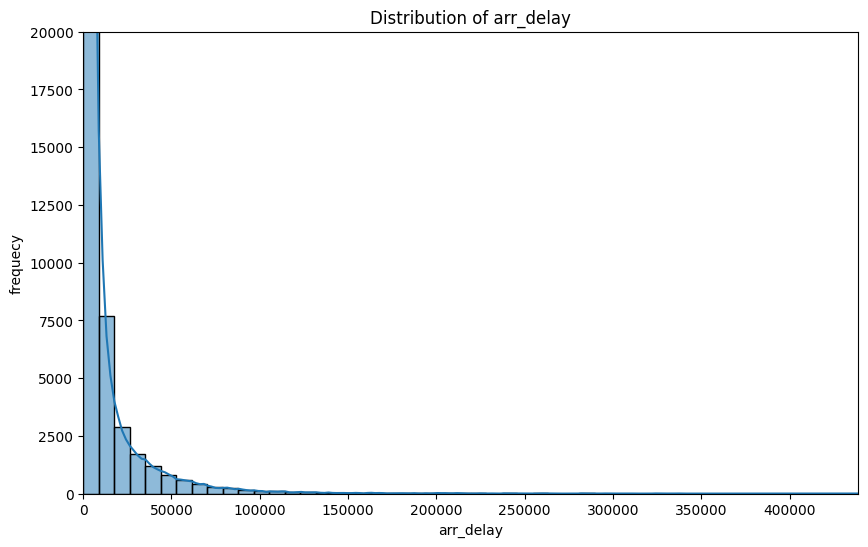

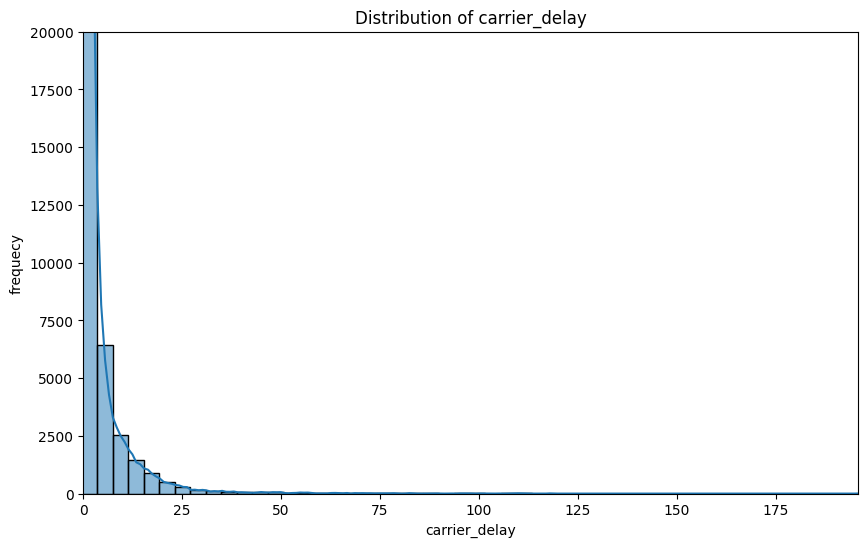

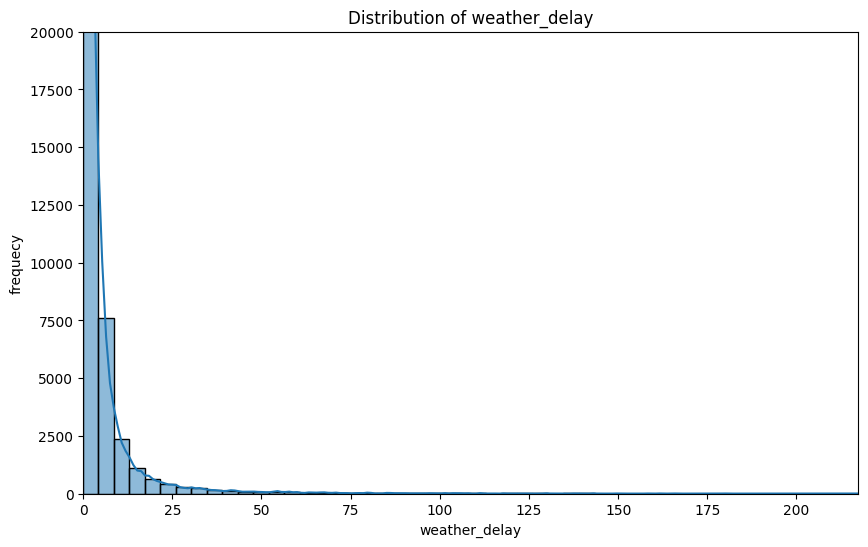

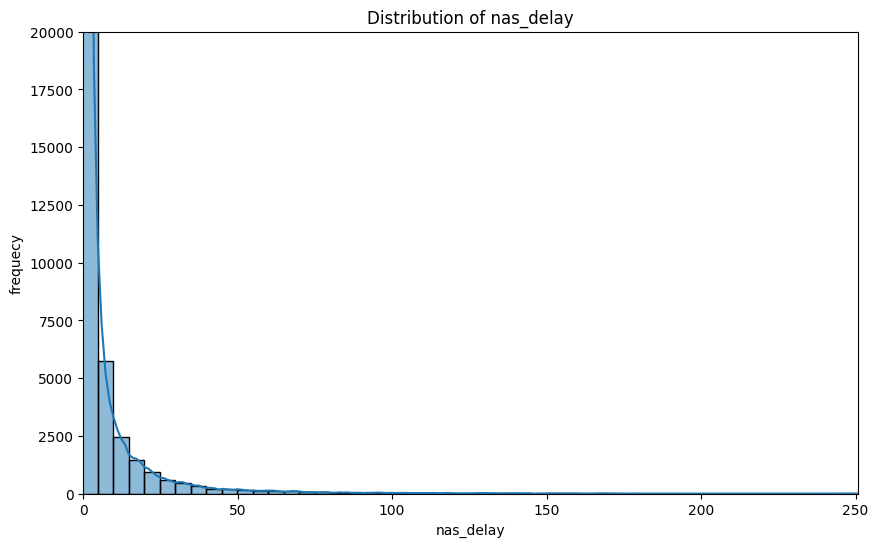

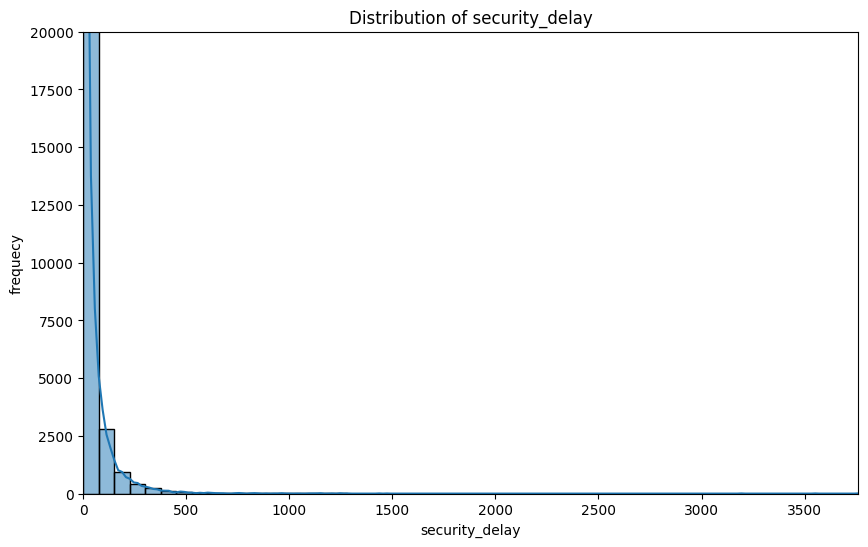

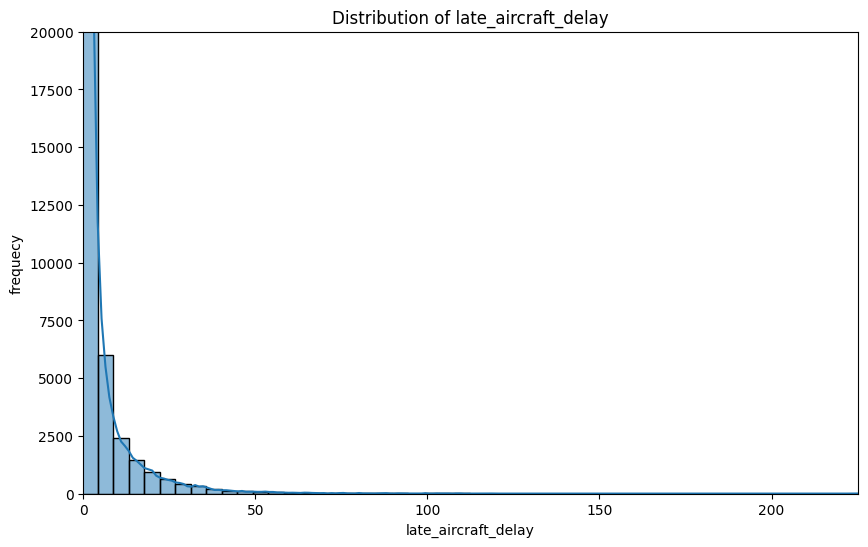

In [ ]:
# numerical attributes to check distribution

numerical_columns = [
    'arr_flights', 'arr_del15', 'arr_delay',
    'carrier_delay', 'weather_delay', 'nas_delay',
    'security_delay', 'late_aircraft_delay'
]

for col in numerical_columns:
  plt.figure(figsize=(10,6))
  sns.histplot(df[col], bins =50, kde = True)
  plt.title(f"Distribution of {col}")
  plt.xlabel(col)
  plt.ylabel('frequecy')
  plt.xlim(0,df[col].max())
  plt.ylim(0,20000)
  # plt.yscale('log')
  plt.show()

**Distribution of Categorical Attributes**

The countplots are used to visualize thr frequency of each category within categorical attributes. This helps to understand how the data is distributed across months and airports, and detect any imbalances in the dataset.

**Steps:**
1. Categorical columns 'month' and 'airport' were selected.
2. Seaborn's countplot was used to create barplots showing the number of records per categroy.
Note: The carrier column could have been included, but it was dropped after the one-hot encoding for simplicity in visualizations.
3. There is also a plot for the top 10 airports of the highest count, plotted using the order and iloc methods.

**Observations**
1. Almost all bars are of roughly equal height except for that of the 8th month, i.e. August. This might be due to the holiday-season travel patterns.
2. This plot often reveals  few major airports (like ATL, DTW, or AUS) account for a massive percentage of the total records.

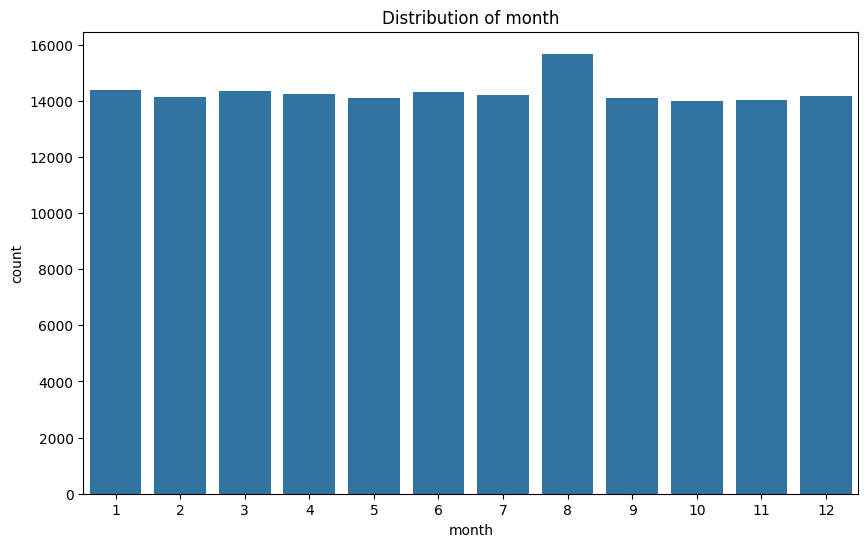

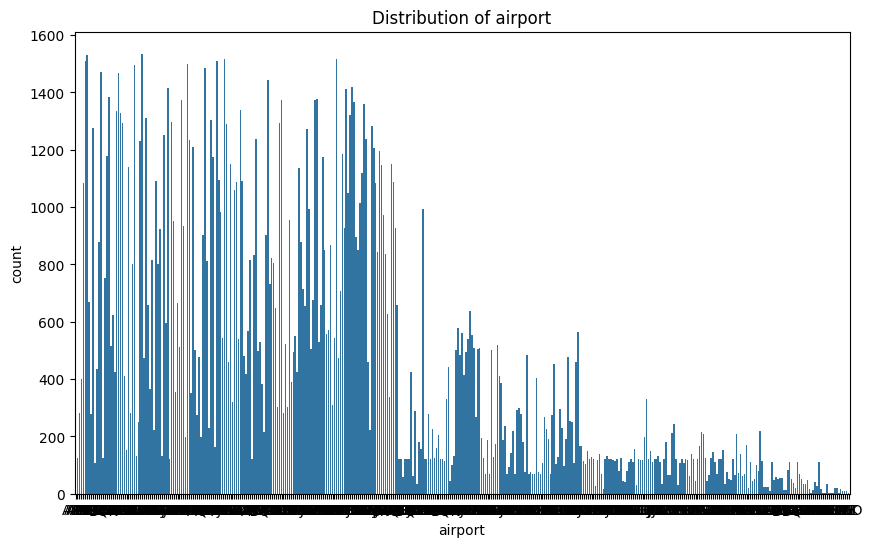

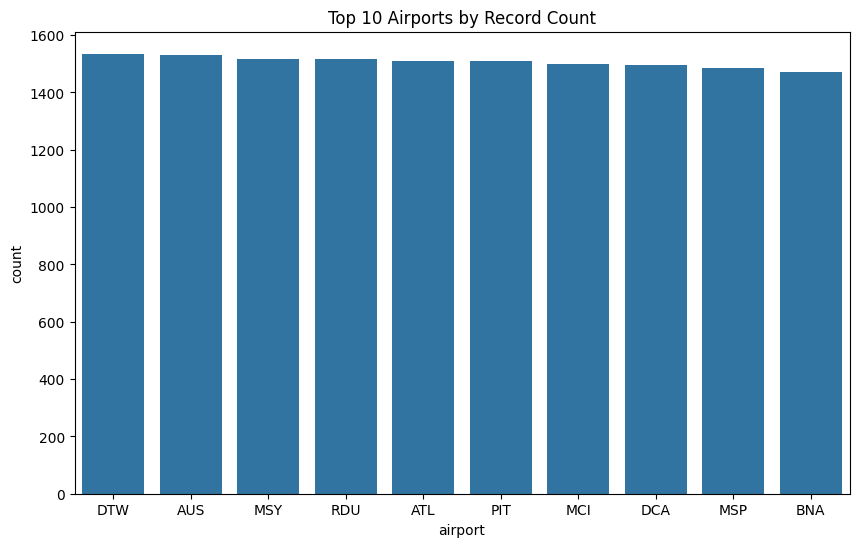

In [ ]:
# categorical attributes to check distribution

# here, we could have included the carrier column, but it was dropped
categorical_columns=[
    'month', 'airport'
]

for col in categorical_columns:
  plt.figure(figsize=(10,6))
  sns.countplot(data= df, x= col)
  plt.title(f"Distribution of {col}")
  plt.show()


plt.figure(figsize=(10,6))
sns.countplot(data=df, x='airport', order=df['airport'].value_counts().iloc[:10].index)
plt.title("Top 10 Airports by Record Count")
plt.show()

**Boxplot: Arrival Delay by Month**

The boxplot visualizes the distribution of arrival delays across different months.

**Steps:**

1. We select the columns 'month' and 'arr_delay'.
2. Seaborn's boxplot creates the visualiztion, with each box showing the IQR, median and potential outliers.

**Observations**

1. Every month features massive outliers (represented by the circles stretching up to 400,000 minutes). This confirms that while the "typical" delay is low, extreme disruptions occur consistently throughout the year.
2. We can see "peaks" in the outliers during months 6 (June), 7 (July), and 12 (December). These correspond to the summer and winter holiday seasons, where a single system failure can cause a massive subsequent number of delays.
3. Despite the massive outliers, the "boxes" at the bottom are very flat. This indicates that the median flight is actually quite punctual.

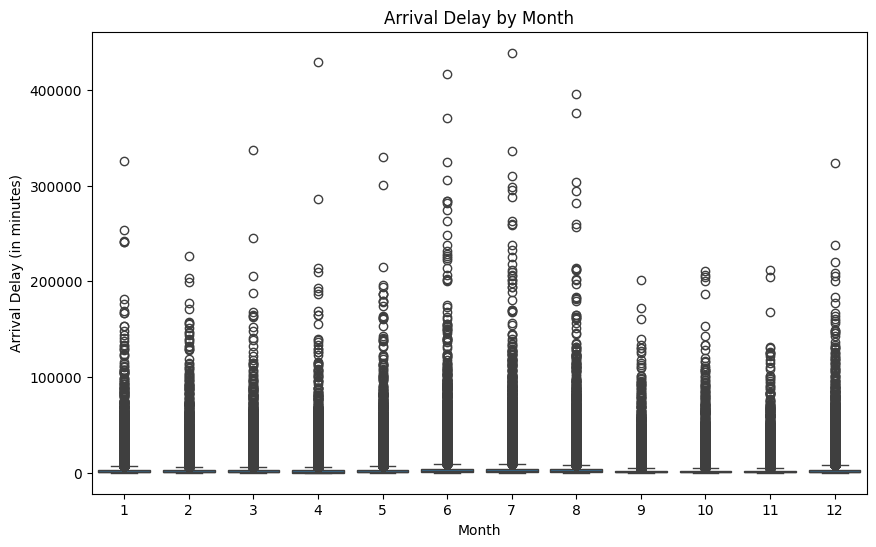

In [ ]:
# arrival delay by month
plt.figure(figsize=(10,6))
sns.boxplot( data = df, x = 'month' , y = 'arr_delay' )
plt.title("Arrival Delay by Month")
plt.xlabel("Month")
plt.ylabel("Arrival Delay (in minutes)")
plt.show()

**Scatterplot: NUmber of Flights vs Flights Delayed by over 15 Minutes**

The scatterplot visualizes the relaionship between the total number of arriving flights (arr_flights) and the number of flights delayed by more than 15 minutes.

**Steps:**
1. arr_flights was selected as the x-column and arr_del15 was selected as the y-column.
2. Seaborn's scatterplot was used to create the plot.


**Observations**

1. As the number of arriving flights increases, the number of flights delayed by more than 15 minutes also increases in a roughly linear fashion.
2. For airports with high traffic (above 15,000 flights), the spread of delays becomes wider. This suggests that while volume drives delays; some high-capacity airports manage the traffic better than others.
3. The dense cluster at lower volumes indicates that most records in the dataset come from smaller airports or less busy time periods where both traffic and delays are low.


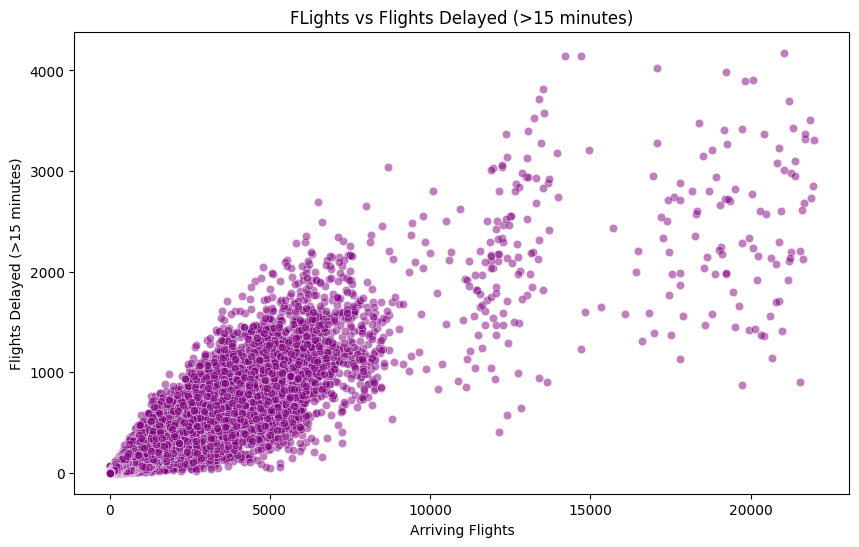

In [ ]:
# number of flights vs delays
plt.figure(figsize=(10,6))
sns.scatterplot( data = df, x = 'arr_flights', y = 'arr_del15' ,alpha = 0.5, color = 'purple')
plt.title("FLights vs Flights Delayed (>15 minutes)")
plt.xlabel("Arriving Flights")
plt.ylabel("Flights Delayed (>15 minutes)")
plt.show()

**Pairplot of Numerical Attributes**

The pairplot is used to visualize the pairwise relationships between multiple numerical variables simultaneously. It provides a comprehensive overview of correlations between variables, distribution patterns of each numerical attribute, potential clusters or linear relationships.

**Steps:**
1. The numerical columns are selected.
2. Since pairplots can become computationally heavy and clustered with large datasets, a sample of 500 records was selected.
3. Seaborn's pairplot() function was used to create the plot.

**Observations:**

1. Most delay-cause variables (like carrier_delay and late_aircraft_delay) show a strong linear trend when plotted against arr_delay. This confirms that total delay time is a direct summation of these individual components.
2. The histograms along the diagonal show that every single numerical attribute in this dataset is heavily right-skewed. This means the "typical" day has very few delays, but the "tail" of extreme events is very long.
3. The scatterplots in the pairplot visually mirror the numbers found in the Correlation Heatmap. For example, the tightest cluster of dots are between arr_del15 and arr_delay, reflecting their 0.97 correlation coefficient.

In [ ]:
plt.figure(figsize = (10,6))
sns.pairplot(df[numerical_columns].sample(n=500, random_state=42), diag_kind='hist', plot_kws={'alpha':0.5})
plt.suptitle("Pairplot of Numerical Attributes", y = 1.02)
plt.show()